In [1]:
import sys
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.model import SimpleTransformer
from scripts.data_gen import generate_ou_process
from scripts.inference import autoregressive_predict

cfg = load_full_config()

In [ ]:
def predict_and_visualize(model_path, device='cpu'):
    model = SimpleTransformer(**cfg['architecture'])
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    model.to(device)

    full_path = generate_ou_process(batch_size=1, time_steps=150) 
    history = full_path[:, :100, :] # (1, 100, 1)
    true_future = full_path[:, 100:, :] # (1, 50, 1)

    current_seq = history.clone().to(device)
    predictions = []
    
    last_attention_map = None 
    
    with torch.no_grad():
        for _ in range(50):
            output, maps = model(current_seq)
            next_val = output[:, -1, :]
            predictions.append(next_val.item())
            
            # Update sequence
            next_val_reshaped = next_val.unsqueeze(1)
            current_seq = torch.cat([current_seq[:, 1:, :], next_val_reshaped], dim=1)
            
            # Grab the map from the first layer (index 0)
            last_attention_map = maps[0].squeeze().cpu().numpy()

    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    # Plot A: The Trajectory
    t_hist = range(100)
    t_fut = range(100, 150)
    
    ax[0].plot(t_hist, history.squeeze(), label='History', color='black')
    ax[0].plot(t_fut, true_future.squeeze(), label='Ground Truth', color='green', alpha=0.6)
    ax[0].plot(t_fut, predictions, label='Model Prediction', color='red', linestyle='--')
    ax[0].set_title("OU Process Extrapolation")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # Plot B: The Attention Map
    sns.heatmap(last_attention_map, ax=ax[1], cmap="viridis")
    ax[1].set_title("Attention Map (Final Step)")
    ax[1].set_xlabel("Key Position (Time Step 0-99)")
    ax[1].set_ylabel("Query Position (Time Step 0-99)")
    
    plt.show()

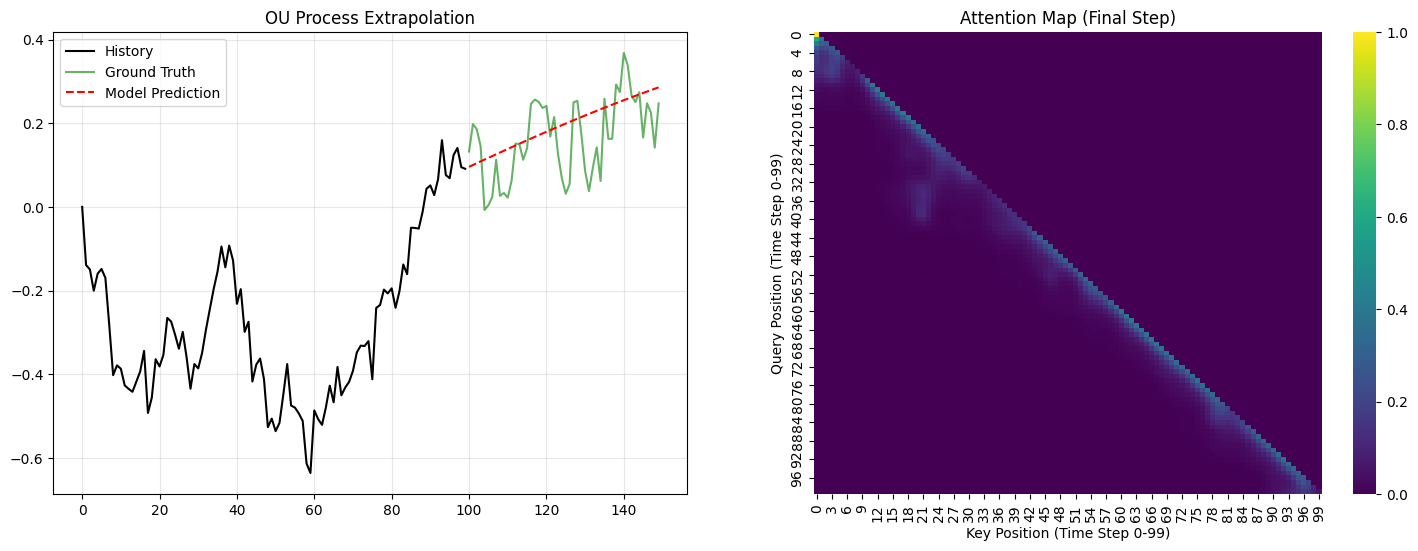

In [ ]:
predict_and_visualize('../experiments/model_v1.pth')